In [75]:
import requests
import pandas as pd

# Enlace de la API
api_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# Cargar los datos directamente desde la API
try:
    response = requests.get(api_url)
    response.raise_for_status()  # Lanzar una excepción para códigos de estado de error (4xx o 5xx)
    data = response.json()

    # Convertir los datos a un DataFrame de Pandas
    df = pd.DataFrame(data)

    print("Datos cargados exitosamente de la API.")
    print("Primeras 5 filas del DataFrame:")
    display(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error al cargar los datos de la API: {e}")
except ValueError as e:
    print(f"Error al decodificar JSON: {e}. Asegúrate de que la API devuelve JSON válido.")

Datos cargados exitosamente de la API.
Primeras 5 filas del DataFrame:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [76]:
# Extraer información de la columna 'account' y crear nuevas columnas
df = pd.concat([df.drop('account', axis=1), df['account'].apply(pd.Series)], axis=1)

print("DataFrame después de aplanar la columna 'account':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

DataFrame después de aplanar la columna 'account':


,customerID,Churn,customer,phone,internet,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...",One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...",Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...",Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...",Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...",Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   customer          7267 non-null   object
 3   phone             7267 non-null   object
 4   internet          7267 non-null   object
 5   Contract          7267 non-null   object
 6   PaperlessBilling  7267 non-null   object
 7   PaymentMethod     7267 non-null   object
 8   Charges           7267 non-null   object
dtypes: object(9)
memory usage: 511.1+ KB


In [77]:
# Extraer información de la columna 'internet' y crear nuevas columnas
df = pd.concat([df.drop('internet', axis=1), df['internet'].apply(pd.Series)], axis=1)

print("DataFrame después de aplanar la columna 'internet':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

DataFrame después de aplanar la columna 'internet':


,customerID,Churn,customer,phone,Contract,PaperlessBilling,PaymentMethod,Charges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}",One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}",DSL,No,Yes,No,Yes,Yes,No
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}",Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}",DSL,No,No,No,No,No,Yes
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}",Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}",Fiber optic,No,No,Yes,No,No,No
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}",Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}",Fiber optic,No,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}",Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}",Fiber optic,No,No,No,Yes,Yes,No



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   customer          7267 non-null   object
 3   phone             7267 non-null   object
 4   Contract          7267 non-null   object
 5   PaperlessBilling  7267 non-null   object
 6   PaymentMethod     7267 non-null   object
 7   Charges           7267 non-null   object
 8   InternetService   7267 non-null   object
 9   OnlineSecurity    7267 non-null   object
 10  OnlineBackup      7267 non-null   object
 11  DeviceProtection  7267 non-null   object
 12  TechSupport       7267 non-null   object
 13  StreamingTV       7267 non-null   object
 14  StreamingMovies   7267 non-null   object
dtypes: object(15)
memory usage: 851.7+ KB


In [78]:
# Extraer información de la columna 'phone' y crear nuevas columnas
df = pd.concat([df.drop('phone', axis=1), df['phone'].apply(pd.Series)], axis=1)

print("DataFrame después de aplanar la columna 'phone':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

DataFrame después de aplanar la columna 'phone':


,customerID,Churn,customer,Contract,PaperlessBilling,PaymentMethod,Charges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...",One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}",DSL,No,Yes,No,Yes,Yes,No,Yes,No
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...",Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}",DSL,No,No,No,No,No,Yes,Yes,Yes
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...",Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}",Fiber optic,No,No,Yes,No,No,No,Yes,No
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...",Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}",Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...",Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}",Fiber optic,No,No,No,Yes,Yes,No,Yes,No



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   customer          7267 non-null   object
 3   Contract          7267 non-null   object
 4   PaperlessBilling  7267 non-null   object
 5   PaymentMethod     7267 non-null   object
 6   Charges           7267 non-null   object
 7   InternetService   7267 non-null   object
 8   OnlineSecurity    7267 non-null   object
 9   OnlineBackup      7267 non-null   object
 10  DeviceProtection  7267 non-null   object
 11  TechSupport       7267 non-null   object
 12  StreamingTV       7267 non-null   object
 13  StreamingMovies   7267 non-null   object
 14  PhoneService      7267 non-null   object
 15  MultipleLines     7267 non-null   object
dtypes: object(16

In [79]:
# Extraer información de la columna 'customer' y crear nuevas columnas
df = pd.concat([df.drop('customer', axis=1), df['customer'].apply(pd.Series)], axis=1)

print("DataFrame después de aplanar la columna 'customer':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

DataFrame después de aplanar la columna 'customer':


,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,Charges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure
0,0002-ORFBO,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}",DSL,No,Yes,No,Yes,Yes,No,Yes,No,Female,0,Yes,Yes,9
1,0003-MKNFE,No,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}",DSL,No,No,No,No,No,Yes,Yes,Yes,Male,0,No,No,9
2,0004-TLHLJ,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}",Fiber optic,No,No,Yes,No,No,No,Yes,No,Male,0,No,No,4
3,0011-IGKFF,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}",Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No,Male,1,Yes,No,13
4,0013-EXCHZ,Yes,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}",Fiber optic,No,No,No,Yes,Yes,No,Yes,No,Female,1,Yes,No,3



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   Contract          7267 non-null   object
 3   PaperlessBilling  7267 non-null   object
 4   PaymentMethod     7267 non-null   object
 5   Charges           7267 non-null   object
 6   InternetService   7267 non-null   object
 7   OnlineSecurity    7267 non-null   object
 8   OnlineBackup      7267 non-null   object
 9   DeviceProtection  7267 non-null   object
 10  TechSupport       7267 non-null   object
 11  StreamingTV       7267 non-null   object
 12  StreamingMovies   7267 non-null   object
 13  PhoneService      7267 non-null   object
 14  MultipleLines     7267 non-null   object
 15  gender            7267 non-null   object
 16  SeniorCitize

In [80]:
print("Información general del DataFrame (tipos de datos y valores no nulos):")
df.info()

Información general del DataFrame (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   Contract          7267 non-null   object
 3   PaperlessBilling  7267 non-null   object
 4   PaymentMethod     7267 non-null   object
 5   Charges           7267 non-null   object
 6   InternetService   7267 non-null   object
 7   OnlineSecurity    7267 non-null   object
 8   OnlineBackup      7267 non-null   object
 9   DeviceProtection  7267 non-null   object
 10  TechSupport       7267 non-null   object
 11  StreamingTV       7267 non-null   object
 12  StreamingMovies   7267 non-null   object
 13  PhoneService      7267 non-null   object
 14  MultipleLines     7267 non-null   object
 15  gender            7267 non-null   o

In [81]:
print("\nEstadísticas descriptivas del DataFrame:")
display(df.describe(include='all'))


Estadísticas descriptivas del DataFrame:


,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,Charges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267,7267,7267.000000
unique,7267,3,3,2,4,6789,3,3,3,3,3,3,3,2,3,2,NaN,2,2,NaN
top,9995-HOTOH,No,Month-to-month,Yes,Electronic check,"{'Monthly': 20.2, 'Total': '20.2'}",Fiber optic,No,No,No,No,No,No,Yes,No,Male,NaN,No,No,NaN
freq,1,5174,4005,4311,2445,11,3198,3608,3182,3195,3582,2896,2870,6560,3495,3675,NaN,3749,5086,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000


In [82]:
# Extraer 'Monthly' y 'Total' de la columna 'Charges'
df['MonthlyCharges'] = df['Charges'].apply(lambda x: x.get('Monthly') if isinstance(x, dict) else None)
df['TotalCharges'] = df['Charges'].apply(lambda x: x.get('Total') if isinstance(x, dict) else None)

# Eliminar la columna 'Charges' original
df = df.drop('Charges', axis=1)

# Convertir las nuevas columnas a tipo numérico, forzando errores a NaN
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("DataFrame después de procesar la columna 'Charges':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

print("\nValores nulos después de la conversión de 'Charges':")
print(df[['MonthlyCharges', 'TotalCharges']].isnull().sum())

DataFrame después de procesar la columna 'Charges':


,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges
0,0002-ORFBO,No,One year,Yes,Mailed check,DSL,No,Yes,No,Yes,...,No,Yes,No,Female,0,Yes,Yes,9,65.6,593.30
1,0003-MKNFE,No,Month-to-month,No,Mailed check,DSL,No,No,No,No,...,Yes,Yes,Yes,Male,0,No,No,9,59.9,542.40
2,0004-TLHLJ,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,No,Yes,No,...,No,Yes,No,Male,0,No,No,4,73.9,280.85
3,0011-IGKFF,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,Yes,Yes,No,...,Yes,Yes,No,Male,1,Yes,No,13,98.0,1237.85
4,0013-EXCHZ,Yes,Month-to-month,Yes,Mailed check,Fiber optic,No,No,No,Yes,...,No,Yes,No,Female,1,Yes,No,3,83.9,267.40



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   Contract          7267 non-null   object 
 3   PaperlessBilling  7267 non-null   object 
 4   PaymentMethod     7267 non-null   object 
 5   InternetService   7267 non-null   object 
 6   OnlineSecurity    7267 non-null   object 
 7   OnlineBackup      7267 non-null   object 
 8   DeviceProtection  7267 non-null   object 
 9   TechSupport       7267 non-null   object 
 10  StreamingTV       7267 non-null   object 
 11  StreamingMovies   7267 non-null   object 
 12  PhoneService      7267 non-null   object 
 13  MultipleLines     7267 non-null   object 
 14  gender            7267 non-null   object 
 15  SeniorCitizen     7267 non-null   int64  

In [83]:
# Eliminar la columna 'customerID' ya que es un identificador único y no aporta valor predictivo
df = df.drop('customerID', axis=1)

print("DataFrame después de eliminar 'customerID':")
display(df.head())
print("\nInformación general del DataFrame actualizada:")
df.info()

DataFrame después de eliminar 'customerID':


,Churn,Contract,PaperlessBilling,PaymentMethod,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges
0,No,One year,Yes,Mailed check,DSL,No,Yes,No,Yes,Yes,No,Yes,No,Female,0,Yes,Yes,9,65.6,593.30
1,No,Month-to-month,No,Mailed check,DSL,No,No,No,No,No,Yes,Yes,Yes,Male,0,No,No,9,59.9,542.40
2,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,No,Yes,No,No,No,Yes,No,Male,0,No,No,4,73.9,280.85
3,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No,Male,1,Yes,No,13,98.0,1237.85
4,Yes,Month-to-month,Yes,Mailed check,Fiber optic,No,No,No,Yes,Yes,No,Yes,No,Female,1,Yes,No,3,83.9,267.40



Información general del DataFrame actualizada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   Contract          7267 non-null   object 
 2   PaperlessBilling  7267 non-null   object 
 3   PaymentMethod     7267 non-null   object 
 4   InternetService   7267 non-null   object 
 5   OnlineSecurity    7267 non-null   object 
 6   OnlineBackup      7267 non-null   object 
 7   DeviceProtection  7267 non-null   object 
 8   TechSupport       7267 non-null   object 
 9   StreamingTV       7267 non-null   object 
 10  StreamingMovies   7267 non-null   object 
 11  PhoneService      7267 non-null   object 
 12  MultipleLines     7267 non-null   object 
 13  gender            7267 non-null   object 
 14  SeniorCitizen     7267 non-null   int64  
 15  Partner           7267 non-null   object 

In [84]:
# Eliminar las filas con valores nulos en 'TotalCharges'
df.dropna(subset=['TotalCharges'], inplace=True)

print("DataFrame después de eliminar filas con nulos en 'TotalCharges':")
display(df.head())
print("\nInformación general del DataFrame actualizada (conteo de no nulos):")
df.info()

DataFrame después de eliminar filas con nulos en 'TotalCharges':


,Churn,Contract,PaperlessBilling,PaymentMethod,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges
0,No,One year,Yes,Mailed check,DSL,No,Yes,No,Yes,Yes,No,Yes,No,Female,0,Yes,Yes,9,65.6,593.30
1,No,Month-to-month,No,Mailed check,DSL,No,No,No,No,No,Yes,Yes,Yes,Male,0,No,No,9,59.9,542.40
2,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,No,Yes,No,No,No,Yes,No,Male,0,No,No,4,73.9,280.85
3,Yes,Month-to-month,Yes,Electronic check,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No,Male,1,Yes,No,13,98.0,1237.85
4,Yes,Month-to-month,Yes,Mailed check,Fiber optic,No,No,No,Yes,Yes,No,Yes,No,Female,1,Yes,No,3,83.9,267.40



Información general del DataFrame actualizada (conteo de no nulos):
<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7256 non-null   object 
 1   Contract          7256 non-null   object 
 2   PaperlessBilling  7256 non-null   object 
 3   PaymentMethod     7256 non-null   object 
 4   InternetService   7256 non-null   object 
 5   OnlineSecurity    7256 non-null   object 
 6   OnlineBackup      7256 non-null   object 
 7   DeviceProtection  7256 non-null   object 
 8   TechSupport       7256 non-null   object 
 9   StreamingTV       7256 non-null   object 
 10  StreamingMovies   7256 non-null   object 
 11  PhoneService      7256 non-null   object 
 12  MultipleLines     7256 non-null   object 
 13  gender            7256 non-null   object 
 14  SeniorCitizen     7256 non-null   int64  
 15  Partner           7256 no

### Codificación de variables binarias y multicategóricas

In [85]:
# Mapeo de columnas 'Yes'/'No' a 1/0
binary_cols = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Primero, manejar los valores vacíos en 'Churn' antes de mapear
df['Churn'] = df['Churn'].replace('', 'No') # Asumimos que los vacíos son 'No churn'

for col in binary_cols:
    # Asegurarse de que 'No internet service' o 'No phone service' se traten como 'No' antes de mapear
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Mapeo de la columna 'gender' a 1/0 (Male=1, Female=0)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("DataFrame después de la transformación de variables binarias:")
display(df.head())
print("\nTipos de datos de las columnas actualizados:")
print(df.dtypes)

DataFrame después de la transformación de variables binarias:


,Churn,Contract,PaperlessBilling,PaymentMethod,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges
0,0,One year,1,Mailed check,DSL,0,1,0,1,1,0,1,0,0,0,1,1,9,65.6,593.30
1,0,Month-to-month,0,Mailed check,DSL,0,0,0,0,0,1,1,1,1,0,0,0,9,59.9,542.40
2,1,Month-to-month,1,Electronic check,Fiber optic,0,0,1,0,0,0,1,0,1,0,0,0,4,73.9,280.85
3,1,Month-to-month,1,Electronic check,Fiber optic,0,1,1,0,1,1,1,0,1,1,1,0,13,98.0,1237.85
4,1,Month-to-month,1,Mailed check,Fiber optic,0,0,0,1,1,0,1,0,0,1,1,0,3,83.9,267.40



Tipos de datos de las columnas actualizados:
Churn                 int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
PhoneService          int64
MultipleLines         int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [86]:
# Aplicar One-Hot Encoding a las columnas categóricas restantes (multicategóricas)
# Excluimos 'Churn' que ya se mapeó a binario y es nuestra variable objetivo.
categorical_cols = [
    'Contract', 'PaymentMethod', 'InternetService'
]

# Aplicar One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("DataFrame después de aplicar One-Hot Encoding:")
display(df.head())
print("\nInformación general del DataFrame después del One-Hot Encoding:")
df.info()

DataFrame después de aplicar One-Hot Encoding:


,Churn,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,...,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,1,0,1,0,1,1,0,1,0,...,9,65.6,593.30,1,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,1,1,...,9,59.9,542.40,0,0,0,0,1,0,0
2,1,1,0,0,1,0,0,0,1,0,...,4,73.9,280.85,0,0,0,1,0,1,0
3,1,1,0,1,1,0,1,1,1,0,...,13,98.0,1237.85,0,0,0,1,0,1,0
4,1,1,0,0,0,1,1,0,1,0,...,3,83.9,267.40,0,0,0,0,1,1,0



Información general del DataFrame después del One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7256 non-null   int64  
 1   PaperlessBilling                       7256 non-null   int64  
 2   OnlineSecurity                         7256 non-null   int64  
 3   OnlineBackup                           7256 non-null   int64  
 4   DeviceProtection                       7256 non-null   int64  
 5   TechSupport                            7256 non-null   int64  
 6   StreamingTV                            7256 non-null   int64  
 7   StreamingMovies                        7256 non-null   int64  
 8   PhoneService                           7256 non-null   int64  
 9   MultipleLines                          7256 non-null   int64  
 10  gender      

In [87]:
# Calcular la proporción de clientes que cancelaron (Churn=1) y los que no (Churn=0)
churn_counts = df['Churn'].value_counts()
churn_proportions = df['Churn'].value_counts(normalize=True) * 100

print("Conteo de clientes por estado de Churn:")
print(churn_counts)
print("\nProporción de clientes por estado de Churn (%):")
print(churn_proportions)

# Evaluar el desbalance
# Se usa .get('Yes', 0) para manejar el caso donde 'Yes' podría no estar en el índice (aunque aquí sí está)
# Si 'Churn' ya estuviera codificado a 0/1, se usaría .get(1, 0)
churn_percentage_yes = churn_proportions.get('Yes', 0)

if churn_percentage_yes < 30:
    print("\nAdvertencia: Existe un desbalance significativo en las clases (Churn es menor al 30%). Esto podría impactar el entrenamiento de modelos predictivos y requerir técnicas de manejo de desbalance (ej. oversampling, undersampling, SMOTE).")
else:
    print("\nLas clases de Churn parecen estar razonablemente balanceadas.")

# Recordatorio: Asegúrate de que la columna 'Churn' esté codificada como 0/1 antes de realizar análisis predictivos.

Conteo de clientes por estado de Churn:
Churn
0    5387
1    1869
Name: count, dtype: int64

Proporción de clientes por estado de Churn (%):
Churn
0    74.242007
1    25.757993
Name: proportion, dtype: float64

Advertencia: Existe un desbalance significativo en las clases (Churn es menor al 30%). Esto podría impactar el entrenamiento de modelos predictivos y requerir técnicas de manejo de desbalance (ej. oversampling, undersampling, SMOTE).


In [88]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Separar características (X) y la variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Distribución original de la clase: {Counter(y)}")

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nDistribución de la clase después de SMOTE: {Counter(y_resampled)}")

# Opcional: Convertir a DataFrame para visualizar o continuar el procesamiento
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Churn')], axis=1)
print("\nPrimeras 5 filas del DataFrame balanceado (después de SMOTE):")
display(df_resampled.head())

Distribución original de la clase: Counter({0: 5387, 1: 1869})

Distribución de la clase después de SMOTE: Counter({0: 5387, 1: 5387})

Primeras 5 filas del DataFrame balanceado (después de SMOTE):


,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,...,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,Churn
0,1,0,1,0,1,1,0,1,0,0,...,65.6,593.30,1,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1,1,1,1,...,59.9,542.40,0,0,0,0,1,0,0,0
2,1,0,0,1,0,0,0,1,0,1,...,73.9,280.85,0,0,0,1,0,1,0,1
3,1,0,1,1,0,1,1,1,0,1,...,98.0,1237.85,0,0,0,1,0,1,0,1
4,1,0,0,0,1,1,0,1,0,0,...,83.9,267.40,0,0,0,0,1,1,0,1


In [89]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separar las características (X) y la variable objetivo (y) del DataFrame balanceado
X_resampled = df_resampled.drop('Churn', axis=1)
y_resampled = df_resampled['Churn']

# Inicializar y aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Convertir las características escaladas de nuevo a un DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X_resampled.columns)

# Recombinar las características escaladas con la variable objetivo
df_scaled = pd.concat([X_scaled_df, y_resampled.reset_index(drop=True)], axis=1)

print("DataFrame después de la estandarización de las características:")
display(df_scaled.head())
print("\nEstadísticas descriptivas de las características escaladas (primeras columnas):")
display(df_scaled.drop('Churn', axis=1).describe())

DataFrame después de la estandarización de las características:


,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,...,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,Churn
0,0.819088,-0.508427,1.624766,-0.611461,1.951876,1.343502,-0.751263,0.339249,-0.791524,-0.867762,...,-0.088606,-0.664596,2.396284,-0.440071,-0.42236,-0.736511,2.165292,-1.028244,-0.438116,0
1,-1.220870,-0.508427,-0.615473,-0.611461,-0.512328,-0.744323,1.331091,0.339249,1.263386,1.152390,...,-0.287140,-0.687875,-0.417313,-0.440071,-0.42236,-0.736511,2.165292,-1.028244,-0.438116,0
2,0.819088,-0.508427,-0.615473,1.635428,-0.512328,-0.744323,-0.751263,0.339249,-0.791524,1.152390,...,0.200487,-0.807497,-0.417313,-0.440071,-0.42236,1.357753,-0.461831,0.972532,-0.438116,1
3,0.819088,-0.508427,1.624766,1.635428,-0.512328,1.343502,1.331091,0.339249,-0.791524,1.152390,...,1.039904,-0.369806,-0.417313,-0.440071,-0.42236,1.357753,-0.461831,0.972532,-0.438116,1
4,0.819088,-0.508427,-0.615473,-0.611461,1.951876,1.343502,-0.751263,0.339249,-0.791524,-0.867762,...,0.548793,-0.813649,-0.417313,-0.440071,-0.42236,-0.736511,2.165292,0.972532,-0.438116,1



Estadísticas descriptivas de las características escaladas (primeras columnas):


,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,gender,...,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
count,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,...,1.077400e+04,1.077400e+04,1.077400e+04,10774.000000,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04,1.077400e+04
mean,7.452323e-17,-4.220785e-17,4.220785e-17,2.110392e-17,8.441570e-17,4.748383e-17,3.165589e-17,1.965303e-16,7.913971e-17,-6.331177e-17,...,2.110392e-17,-1.055196e-16,6.331177e-17,0.000000,4.220785e-17,2.110392e-17,-2.374191e-17,-4.220785e-17,3.165589e-17,1.055196e-17
std,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,...,1.000046e+00,1.000046e+00,1.000046e+00,1.000046,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00,1.000046e+00
min,-1.220870e+00,-5.084268e-01,-6.154732e-01,-6.114607e-01,-5.123275e-01,-7.443232e-01,-7.512634e-01,-2.947685e+00,-7.915236e-01,-8.677615e-01,...,-1.110646e+00,-1.737833e+00,-9.273480e-01,-0.417313,-4.400713e-01,-4.223598e-01,-7.365108e-01,-4.618315e-01,-1.028244e+00,-4.381164e-01
25%,-1.220870e+00,-5.084268e-01,-6.154732e-01,-6.114607e-01,-5.123275e-01,-7.443232e-01,-7.512634e-01,3.392492e-01,-7.915236e-01,-8.677615e-01,...,-9.436241e-01,-7.817345e-01,-8.123360e-01,-0.417313,-4.400713e-01,-4.223598e-01,-7.365108e-01,-4.618315e-01,-1.028244e+00,-4.381164e-01
50%,8.190883e-01,-5.084268e-01,-6.154732e-01,-6.114607e-01,-5.123275e-01,-7.443232e-01,-7.512634e-01,3.392492e-01,-7.915236e-01,-8.677615e-01,...,-2.755349e-01,2.335569e-01,-4.018895e-01,-0.417313,-4.400713e-01,-4.223598e-01,-7.365108e-01,-4.618315e-01,9.725323e-01,-4.381164e-01
75%,8.190883e-01,-5.084268e-01,1.624766e+00,1.635428e+00,-5.123275e-01,1.343502e+00,1.331091e+00,3.392492e-01,1.263386e+00,1.152390e+00,...,8.518657e-01,8.025556e-01,5.549423e-01,-0.417313,-4.400713e-01,-4.223598e-01,1.357753e+00,-4.618315e-01,9.725323e-01,-4.381164e-01
max,8.190883e-01,1.966851e+00,1.624766e+00,1.635428e+00,1.951876e+00,1.343502e+00,1.331091e+00,3.392492e-01,1.263386e+00,1.152390e+00,...,1.853999e+00,1.762638e+00,3.036115e+00,2.396284,2.272359e+00,2.367649e+00,1.357753e+00,2.165292e+00,9.725323e-01,2.282498e+00


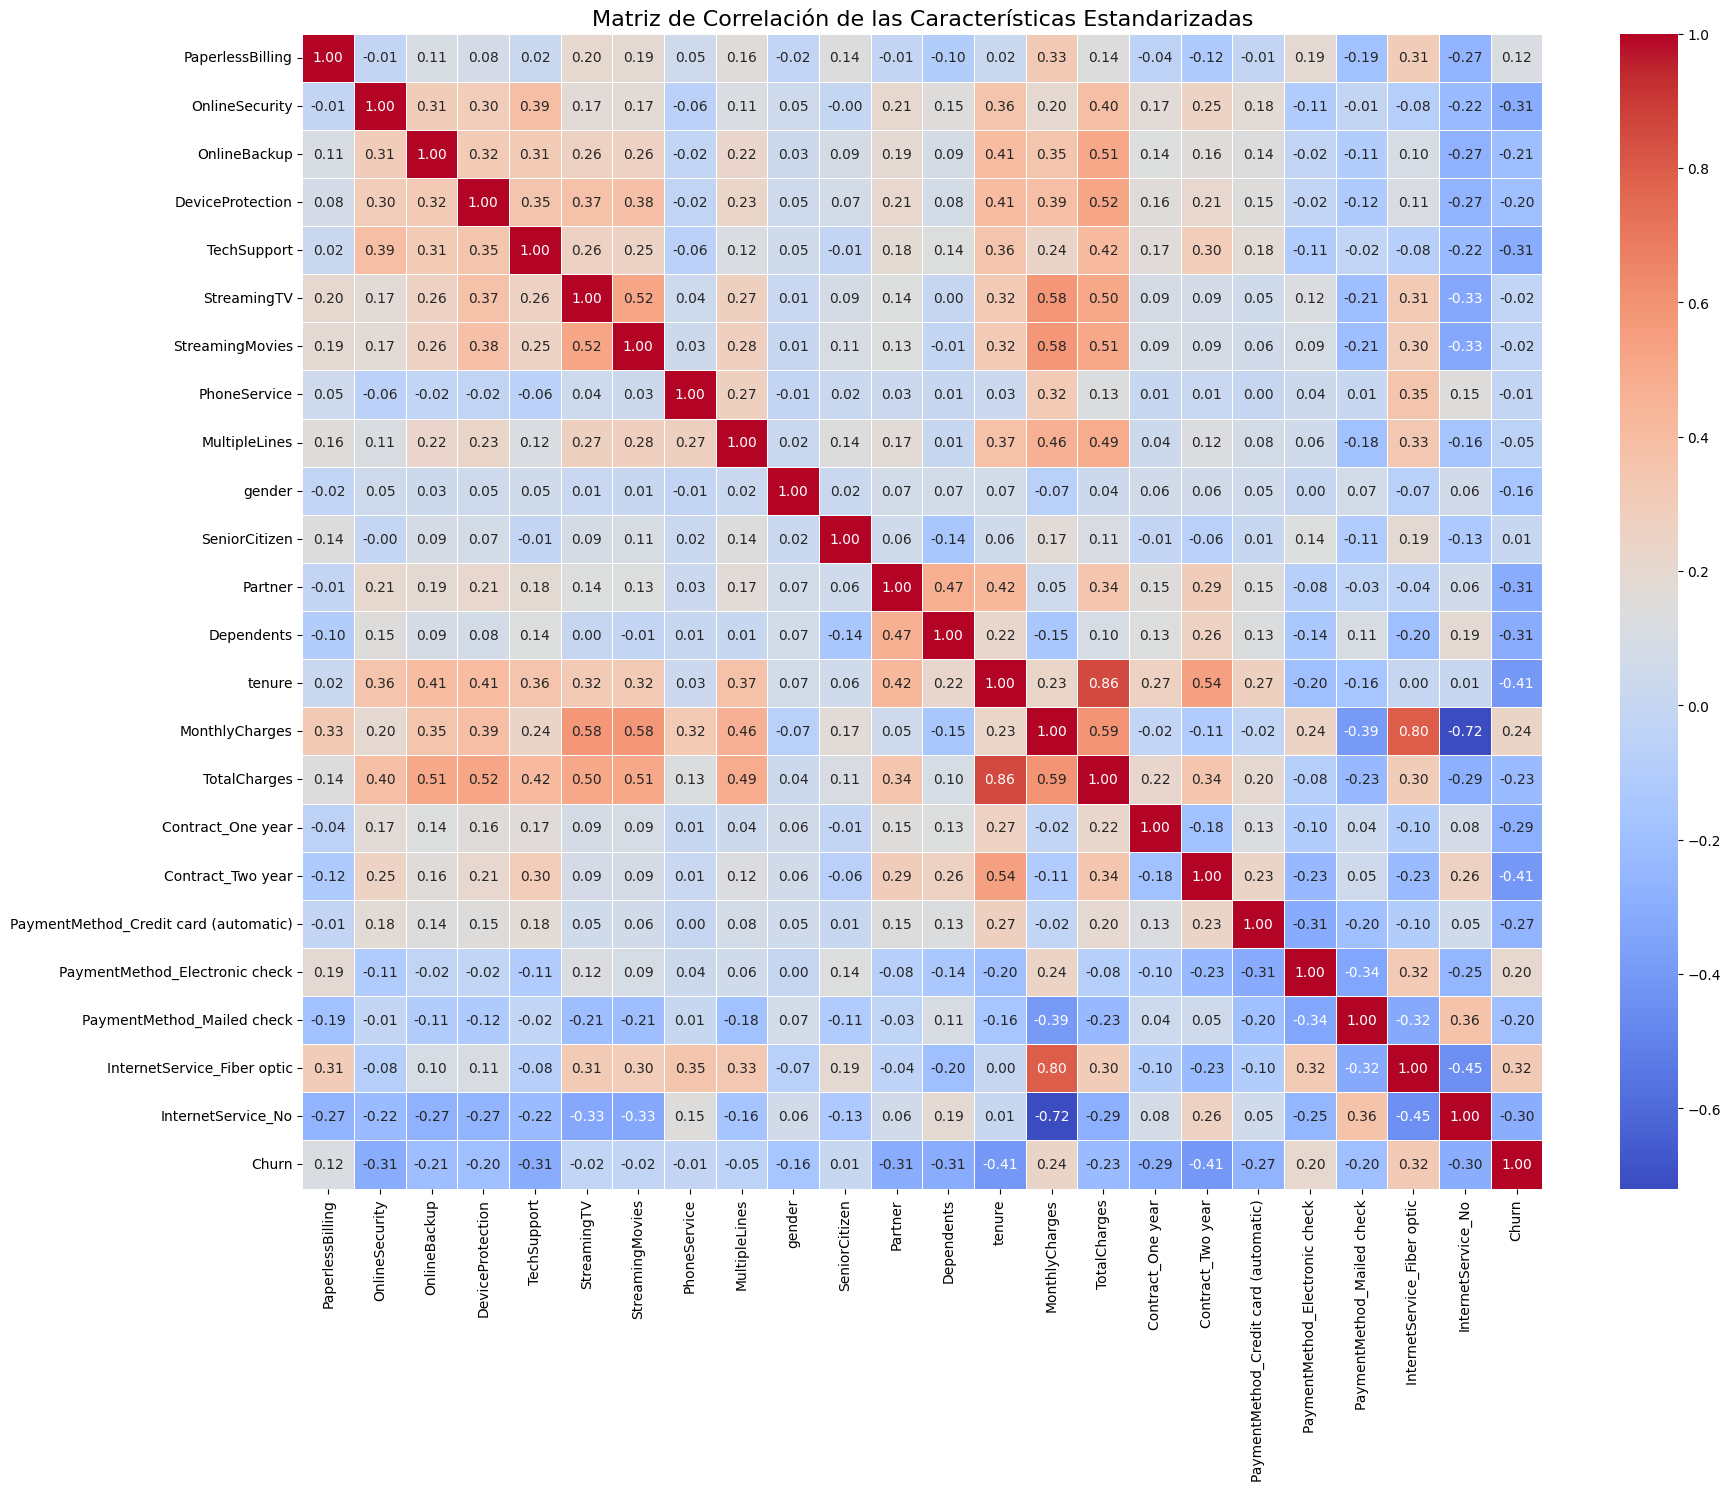


Correlación de las características con 'Churn':
Churn                                    1.000000
InternetService_Fiber optic              0.322197
MonthlyCharges                           0.235071
PaymentMethod_Electronic check           0.202351
PaperlessBilling                         0.119663
SeniorCitizen                            0.011946
PhoneService                            -0.012813
StreamingTV                             -0.019960
StreamingMovies                         -0.020681
MultipleLines                           -0.051878
gender                                  -0.159377
PaymentMethod_Mailed check              -0.196047
DeviceProtection                        -0.198537
OnlineBackup                            -0.206683
TotalCharges                            -0.225944
PaymentMethod_Credit card (automatic)   -0.269057
Contract_One year                       -0.288828
InternetService_No                      -0.300242
TechSupport                             -0.306482
P

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
correlation_matrix = df_scaled.corr()

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(20, 15)) # Ajusta el tamaño de la figura para una mejor visibilidad
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Características Estandarizadas', fontsize=16)
plt.show()

# Mostrar las correlaciones con la variable objetivo 'Churn'
print("\nCorrelación de las características con 'Churn':")
print(correlation_matrix['Churn'].sort_values(ascending=False))

/tmp/ipykernel_156/3869406044.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract_Type', y='Churn', data=df_scaled, palette='viridis')


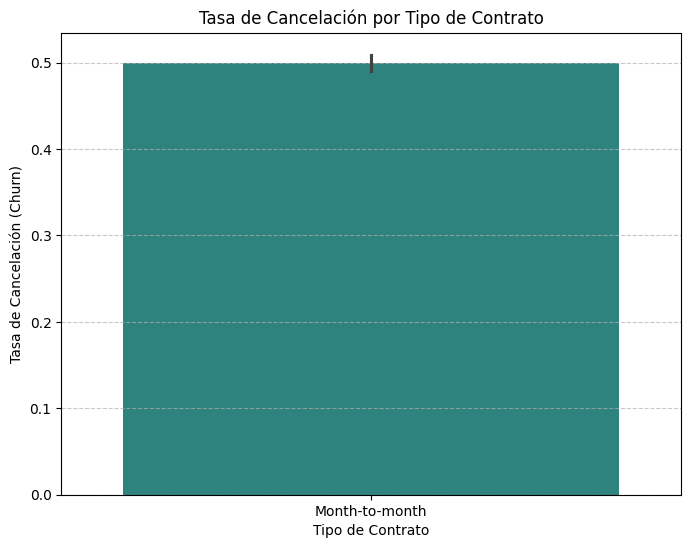

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Relación entre 'Contract' y 'Churn'
# Para visualizar el contrato, necesitamos 'des-one-hot-encode' las columnas o usar el DataFrame original si no está modificado.
# Como hemos estandarizado y usado SMOTE en df_scaled, vamos a recrear el tipo de contrato para visualización.

# Crear una columna 'Contract_Type' en df_scaled para visualización
def get_contract_type(row):
    if row['Contract_One year'] == 1:
        return 'One year'
    elif row['Contract_Two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

df_scaled['Contract_Type'] = df_scaled.apply(get_contract_type, axis=1)

plt.figure(figsize=(8, 6))
sns.barplot(x='Contract_Type', y='Churn', data=df_scaled, palette='viridis')
plt.title('Tasa de Cancelación por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Cancelación (Churn)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_156/229495617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df_scaled, palette='muted')


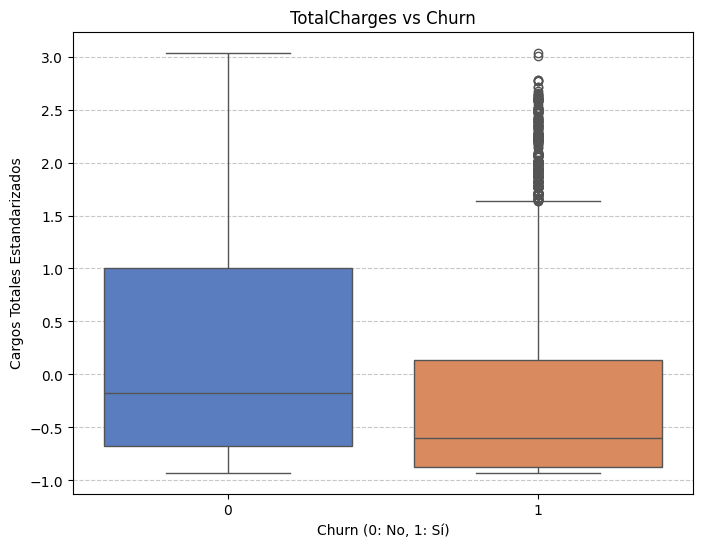

In [92]:
# 2. Relación entre 'TotalCharges' y 'Churn'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df_scaled, palette='muted')
plt.title('TotalCharges vs Churn')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Cargos Totales Estandarizados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_156/2149666524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_scaled, palette='pastel')


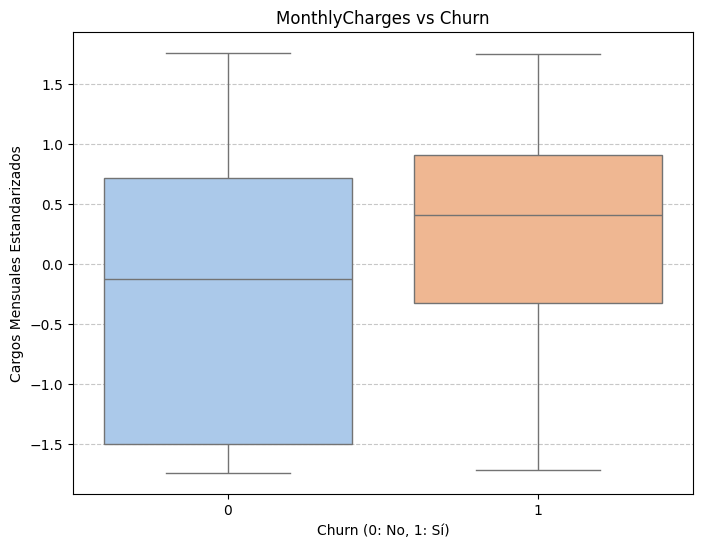

In [93]:
# 3. Relación entre 'MonthlyCharges' y 'Churn'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_scaled, palette='pastel')
plt.title('MonthlyCharges vs Churn')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Cargos Mensuales Estandarizados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

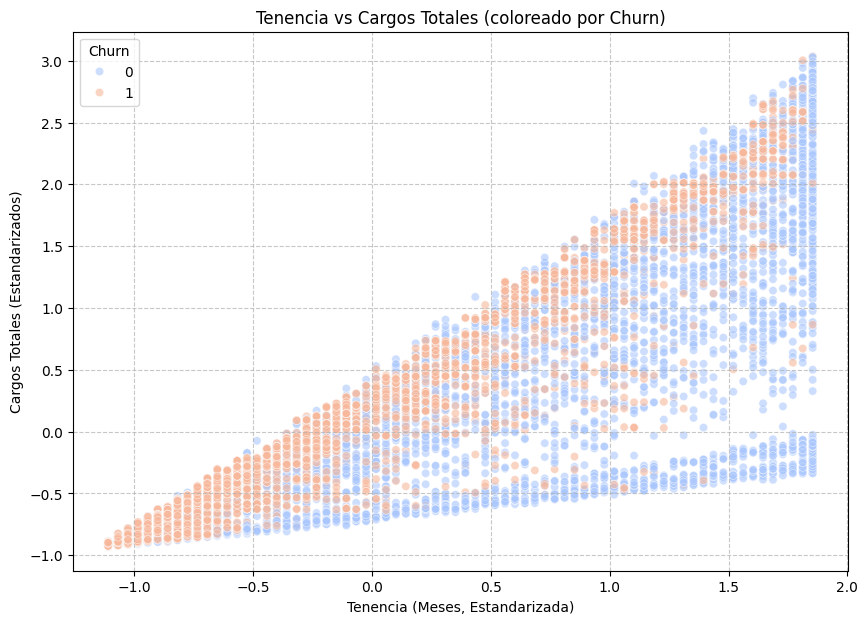

In [94]:
# 4. Relación entre 'tenure' y 'TotalCharges' coloreado por 'Churn'
# Para una mejor visualización, podemos usar el df_scaled directamente para estas variables ya numéricas
plt.figure(figsize=(10, 7))
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_scaled, palette='coolwarm', alpha=0.6)
plt.title('Tenencia vs Cargos Totales (coloreado por Churn)')
plt.xlabel('Tenencia (Meses, Estandarizada)')
plt.ylabel('Cargos Totales (Estandarizados)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [96]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Separar las características (X) y la variable objetivo (y)
X = df_scaled.drop('Churn', axis=1)
y = df_scaled['Churn']

# Eliminar la columna 'Contract_Type' ya que es una columna auxiliar para visualización y no para el modelo
# No tiene sentido en el modelo predictivo
if 'Contract_Type' in X.columns:
    X = X.drop('Contract_Type', axis=1)

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de la clase 'Churn' en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribución de la clase 'Churn' en el conjunto de prueba:")
print(y_test.value_counts(normalize=True) * 100)

Dimensiones de X_train: (8619, 23)
Dimensiones de X_test: (2155, 23)
Dimensiones de y_train: (8619,)
Dimensiones de y_test: (2155,)

Distribución de la clase 'Churn' en el conjunto de entrenamiento:
Churn
1    50.005801
0    49.994199
Name: proportion, dtype: float64

Distribución de la clase 'Churn' en el conjunto de prueba:
Churn
0    50.023202
1    49.976798
Name: proportion, dtype: float64


# Task
Entrena un modelo de Regresión Logística utilizando los conjuntos de entrenamiento `X_train` y `y_train`, y luego extrae y visualiza los coeficientes de las características para determinar su impacto en la probabilidad de cancelación.

## Entrenar Regresión Logística y Analizar Coeficientes

### Analisis:
Entrenar un modelo de Regresión Logística utilizando los conjuntos de entrenamiento `X_train` y `y_train`. Extraer y visualizar los coeficientes de las características para determinar su impacto en la probabilidad de cancelación. Los coeficientes positivos indican un aumento en la probabilidad de cancelación, mientras que los negativos la disminuyen.


Coeficientes del modelo de Regresión Logística (ordenados por impacto absoluto):


,Feature,Coefficient,Abs_Coefficient
14,MonthlyCharges,7.459719,7.459719
21,InternetService_Fiber optic,-2.949144,2.949144
22,InternetService_No,2.100610,2.100610
13,tenure,-1.861203,1.861203
7,PhoneService,-1.806245,1.806245
15,TotalCharges,1.449584,1.449584
6,StreamingMovies,-1.208175,1.208175
5,StreamingTV,-1.143581,1.143581
4,TechSupport,-0.833513,0.833513
1,OnlineSecurity,-0.828588,0.828588


/tmp/ipykernel_156/370425826.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(20), palette='coolwarm') # Mostrar top 20 para claridad


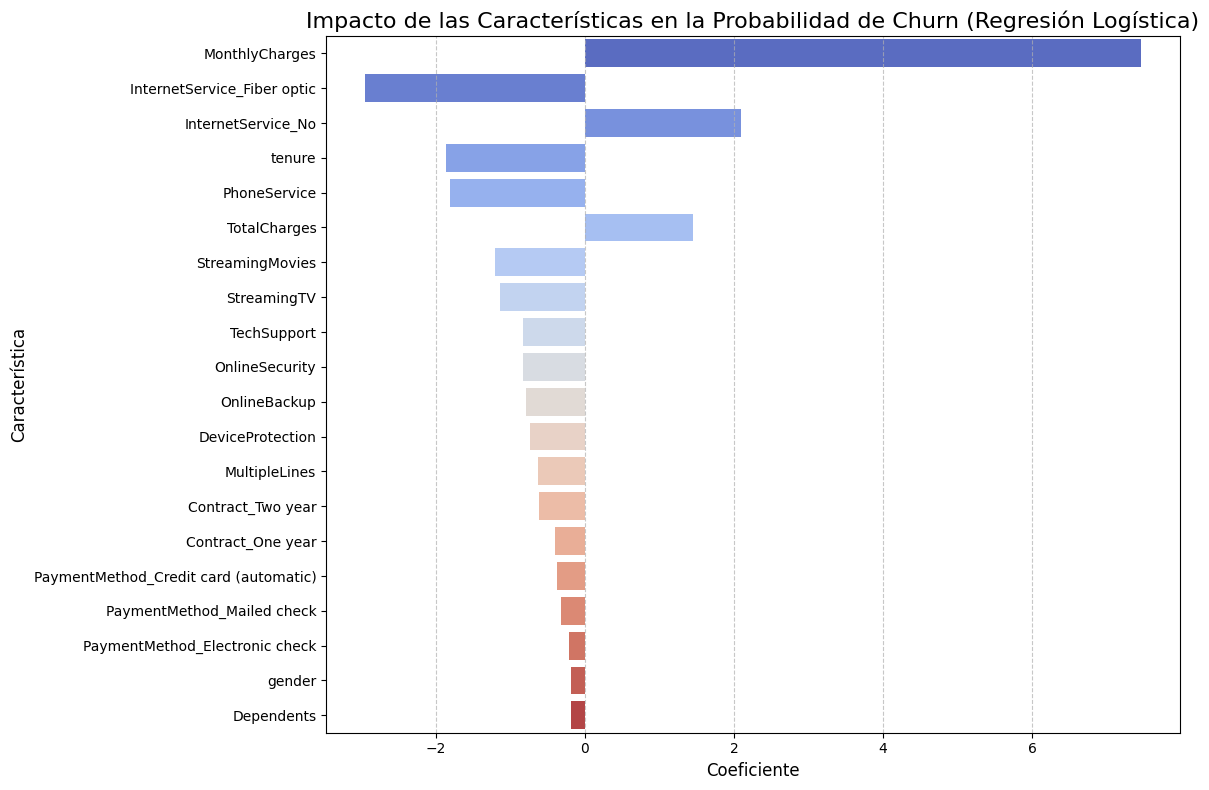

In [97]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inicializar el modelo de Regresión Logística
# Se ajusta max_iter para asegurar la convergencia en datasets más grandes
# El solver 'liblinear' es bueno para datasets pequeños y medianos y permite penalizaciones L1/L2
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# 2. Entrenar el modelo
model.fit(X_train, y_train)

# 3. Extraer los coeficientes y los nombres de las características
coefficients = model.coef_[0]
feature_names = X_train.columns

# 4. Crear un DataFrame para facilitar el análisis
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Ordenar los coeficientes por su valor absoluto para ver los más influyentes
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Coeficientes del modelo de Regresión Logística (ordenados por impacto absoluto):")
display(coef_df)

# 5. Visualizar los coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(20), palette='coolwarm') # Mostrar top 20 para claridad
plt.title('Impacto de las Características en la Probabilidad de Churn (Regresión Logística)', fontsize=16)
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Coeficientes del modelo de Regresión Logística (ordenados por impacto absoluto):


,Feature,Coefficient,Abs_Coefficient
14,MonthlyCharges,7.459719,7.459719
21,InternetService_Fiber optic,-2.949144,2.949144
22,InternetService_No,2.100610,2.100610
13,tenure,-1.861203,1.861203
7,PhoneService,-1.806245,1.806245
15,TotalCharges,1.449584,1.449584
6,StreamingMovies,-1.208175,1.208175
5,StreamingTV,-1.143581,1.143581
4,TechSupport,-0.833513,0.833513
1,OnlineSecurity,-0.828588,0.828588


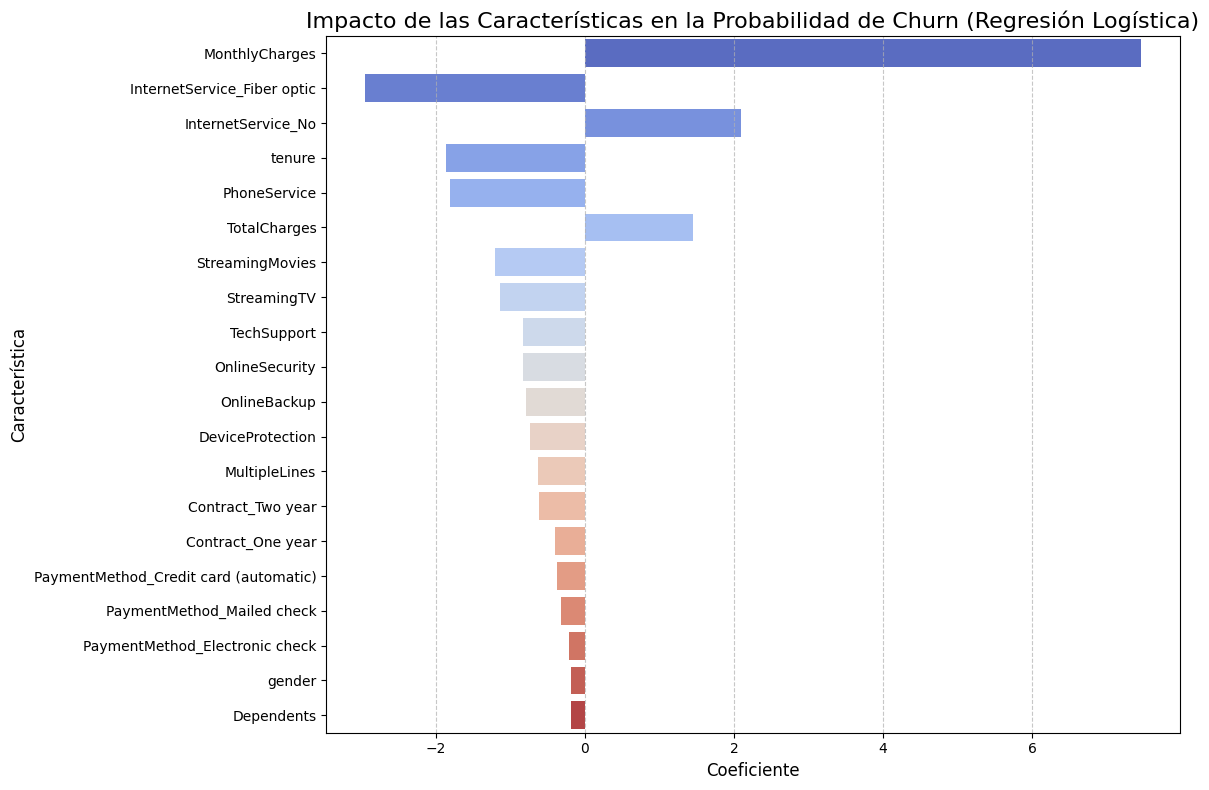

In [98]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inicializar el modelo de Regresión Logística
# Se ajusta max_iter para asegurar la convergencia en datasets más grandes
# El solver 'liblinear' es bueno para datasets pequeños y medianos y permite penalizaciones L1/L2
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# 2. Entrenar el modelo
model.fit(X_train, y_train)

# 3. Extraer los coeficientes y los nombres de las características
coefficients = model.coef_[0]
feature_names = X_train.columns

# 4. Crear un DataFrame para facilitar el análisis
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Ordenar los coeficientes por su valor absoluto para ver los más influyentes
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Coeficientes del modelo de Regresión Logística (ordenados por impacto absoluto):")
display(coef_df)

# 5. Visualizar los coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df.head(20), palette='coolwarm', legend=False) # Mostrar top 20 para claridad
plt.title('Impacto de las Características en la Probabilidad de Churn (Regresión Logística)', fontsize=16)
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Entrenar K-Nearest Neighbors (KNN)

### Analisis:
Entrenar un clasificador KNN con los datos de entrenamiento. Para KNN, la relevancia de las variables se relaciona con cómo contribuyen a la proximidad entre los puntos. Discutir cómo la escala y la dimensionalidad afectan la 'distancia' y, por ende, la influencia de las variables.


In [99]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Inicializar el clasificador KNeighborsClassifier
# Se elige un n_neighbors=5 como punto de partida. Este valor puede optimizarse.
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Entrenar el modelo KNN utilizando los conjuntos de entrenamiento
knn_model.fit(X_train, y_train)

print("Modelo KNN entrenado exitosamente con n_neighbors = 5.")

Modelo KNN entrenado exitosamente con n_neighbors = 5.


El algoritmo K-Nearest Neighbors (KNN) es un clasificador basado en la distancia, lo que significa que predice la clase de un nuevo punto de datos basándose en la proximidad a sus 'k' vecinos más cercanos en el espacio de características. Por lo tanto, cómo se calcula esta 'distancia' es crucial y está directamente influenciada por:

1.  **Escala de las Características**: Como hemos estandarizado las características en `X_train` utilizando `StandardScaler`, todas las variables numéricas ahora tienen una media de 0 y una desviación estándar de 1. Esto es fundamental para KNN porque si las características no estuvieran escaladas, aquellas con rangos de valores más grandes (por ejemplo, `TotalCharges` o `tenure`) dominarían el cálculo de la distancia, haciendo que las características con rangos más pequeños (por ejemplo, binarias o categóricas codificadas) tuvieran un impacto insignificante. La estandarización asegura que todas las características contribuyan equitativamente a la métrica de distancia, lo que permite que KNN considere la verdadera similitud entre los puntos de datos, sin sesgos por la magnitud de las unidades de medida.

2.  **Dimensionalidad (Número de Características)**: A medida que aumenta el número de características (dimensionalidad), el espacio de características se vuelve cada vez más disperso. Este fenómeno se conoce como la "maldición de la dimensionalidad". En un espacio de alta dimensionalidad, la distancia entre cualquier par de puntos de datos tiende a volverse similar, haciendo que sea difícil para KNN encontrar vecinos verdaderamente cercanos. Cuando todas las distancias son parecidas, la noción de "proximidad" pierde significado, y el rendimiento de KNN puede degradarse drásticamente. Esto también implica que algunas características pueden ser irrelevantes o incluso ruidosas, lo que puede confundir al algoritmo si no se realiza una selección o reducción de características previa. Aunque SMOTE ayudó a balancear las clases, la alta dimensionalidad aún puede ser un desafío para KNN, haciendo que el modelo sea más propenso al sobreajuste y menos interpretable en términos de relevancia de variables individuales, ya que todas contribuyen a la distancia de manera compleja.

## Entrenar Random Forest y Analizar Importancia de Variables

### Analisis:
Entrenar un clasificador Random Forest utilizando los datos de entrenamiento. Extraer y visualizar la importancia de las características que proporciona el modelo. Random Forest calcula la importancia basándose en la reducción de la impureza de Gini o la entropía que cada característica aporta durante la construcción de los árboles, revelando las variables más predictivas.


Modelo Random Forest entrenado exitosamente.

Importancia de las características (Random Forest, ordenadas):


,Feature,Importance
14,MonthlyCharges,0.160936
15,TotalCharges,0.143592
13,tenure,0.140537
17,Contract_Two year,0.061592
16,Contract_One year,0.046770
1,OnlineSecurity,0.046724
4,TechSupport,0.044789
21,InternetService_Fiber optic,0.040541
12,Dependents,0.033426
22,InternetService_No,0.033025


/tmp/ipykernel_156/1754456665.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis') # Mostrar top 15


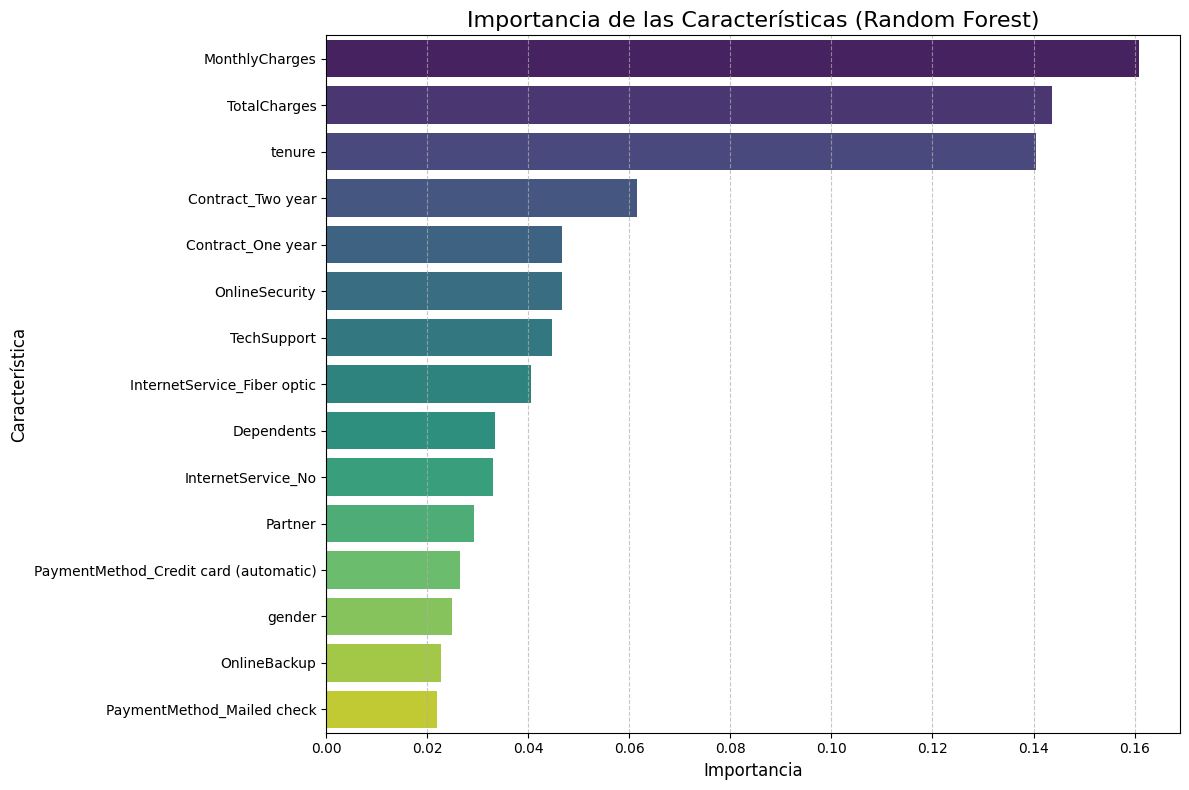

In [100]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Inicializar el clasificador RandomForestClassifier
# Se elige n_estimators=100 y random_state=42 para reproducibilidad.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo Random Forest
rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

# 3. Extraer la importancia de las características
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# 4. Crear un DataFrame para facilitar el análisis
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 5. Ordenar el DataFrame por 'Importance' en orden descendente
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 6. Imprimir la importancia de las características ordenadas
print("\nImportancia de las características (Random Forest, ordenadas):")
display(feature_importance_df)

# 7. Visualizar las top N características más importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis') # Mostrar top 15
plt.title('Importancia de las Características (Random Forest)', fontsize=16)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Modelo Random Forest entrenado exitosamente.

Importancia de las características (Random Forest, ordenadas):


,Feature,Importance
14,MonthlyCharges,0.160936
15,TotalCharges,0.143592
13,tenure,0.140537
17,Contract_Two year,0.061592
16,Contract_One year,0.046770
1,OnlineSecurity,0.046724
4,TechSupport,0.044789
21,InternetService_Fiber optic,0.040541
12,Dependents,0.033426
22,InternetService_No,0.033025


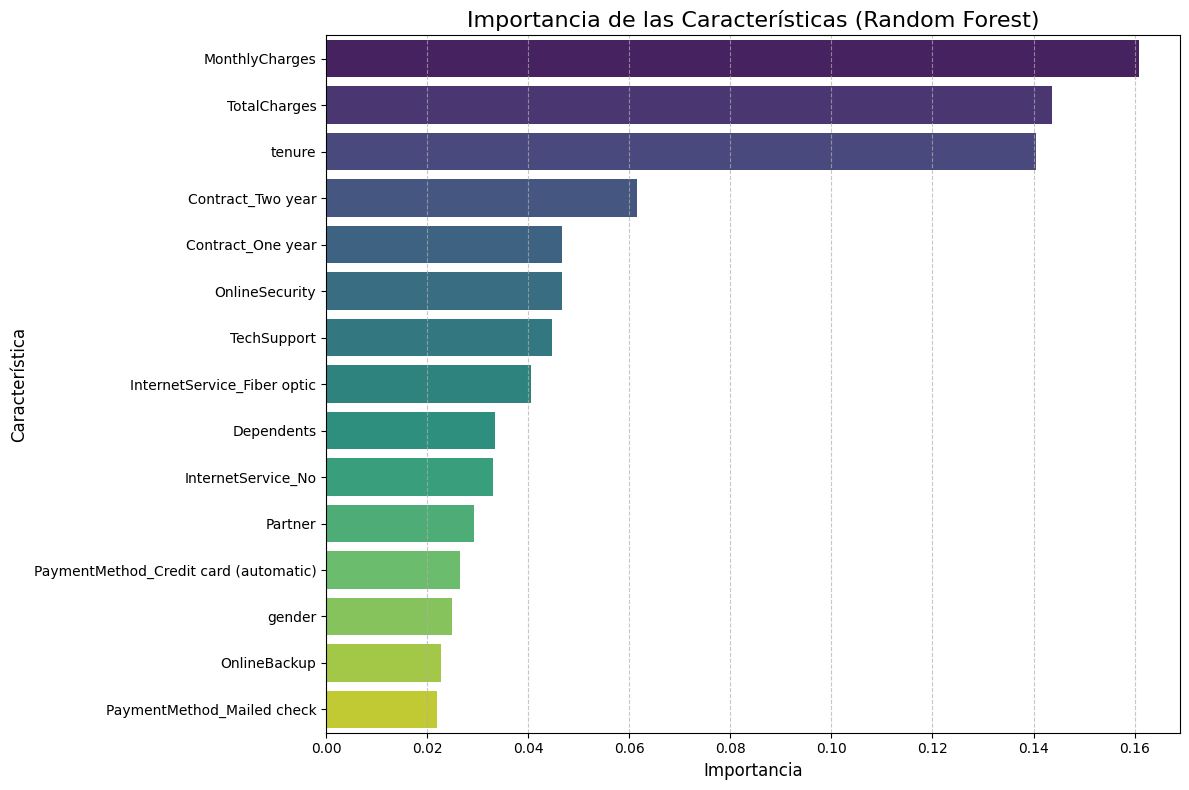

In [101]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Inicializar el clasificador RandomForestClassifier
# Se elige n_estimators=100 y random_state=42 para reproducibilidad.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo Random Forest
rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

# 3. Extraer la importancia de las características
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# 4. Crear un DataFrame para facilitar el análisis
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 5. Ordenar el DataFrame por 'Importance' en orden descendente
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 6. Imprimir la importancia de las características ordenadas
print("\nImportancia de las características (Random Forest, ordenadas):")
display(feature_importance_df)

# 7. Visualizar las top N características más importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(15), palette='viridis', legend=False) # Mostrar top 15
plt.title('Importancia de las Características (Random Forest)', fontsize=16)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Entrenar Support Vector Machine (SVM)

### Subtask:
Entrenar un clasificador SVM con los datos de entrenamiento. Analizar cómo las variables influyen en la frontera de decisión. Para SVMs lineales, se pueden interpretar los coeficientes de las características. Para SVMs no lineales, la interpretación es más compleja, pero se puede discutir la contribución de las variables a la separación de las clases.


In [102]:
from sklearn.svm import SVC

# 1. Inicializar el clasificador SVC con un kernel lineal
# Se elige random_state=42 para reproducibilidad.
# El parámetro C controla el trade-off entre la clasificación correcta de los puntos de entrenamiento y la maximización del margen.
# Un valor por defecto es 1.0.
svm_model = SVC(kernel='linear', random_state=42)

# 2. Entrenar el modelo SVM utilizando los conjuntos de entrenamiento
svm_model.fit(X_train, y_train)

# 3. Imprimir un mensaje indicando que el modelo SVM ha sido entrenado exitosamente.
print("Modelo SVM con kernel lineal entrenado exitosamente.")

Modelo SVM con kernel lineal entrenado exitosamente.


### Análisis de la Influencia de las Variables en la Frontera de Decisión del SVM

El clasificador Support Vector Machine (SVM) con un kernel lineal busca encontrar el hiperplano que mejor separa las clases en el espacio de características, maximizando el margen entre los puntos de datos de las diferentes clases.

**Para SVMs Lineales (como el `svm_model` entrenado):**

Cuando se utiliza un kernel lineal, el modelo SVM produce un conjunto de coeficientes (`model.coef_`) para cada característica, similar a la Regresión Logística. Estos coeficientes representan la pendiente del hiperplano de decisión en la dirección de cada característica. Por lo tanto, su interpretación es bastante directa:

*   **Magnitud de los coeficientes:** Un coeficiente con una mayor magnitud (ya sea positiva o negativa) indica que la característica correspondiente tiene un impacto más significativo en la determinación de la frontera de decisión. Es decir, cambios pequeños en el valor de esa característica resultarán en un movimiento más grande a través del hiperplano de decisión, influyendo fuertemente en la clasificación.
*   **Signo de los coeficientes:**
    *   Un **coeficiente positivo** para una característica significa que un aumento en el valor de esa característica tiende a empujar el punto de datos hacia la clase positiva (en nuestro caso, 'Churn'=1).
    *   Un **coeficiente negativo** significa que un aumento en el valor de esa característica tiende a empujar el punto de datos hacia la clase negativa (en nuestro caso, 'Churn'=0).

En resumen, los coeficientes de un SVM lineal nos permiten entender la dirección y la fuerza con la que cada característica influye en la separación de las clases, indicando cuáles variables son más críticas para predecir la cancelación.

**Cambio de Interpretación con Kernels No Lineales (ej. 'rbf'):**

Si se utilizara un kernel no lineal (como el kernel 'rbf' o 'polinomial'), la interpretación directa de la influencia de las variables cambia significativamente y se vuelve mucho más compleja. Esto se debe a que un kernel no lineal transforma implícitamente el espacio de características original en un espacio de mayor dimensión donde las clases pueden ser linealmente separables. En este espacio transformado:

*   **No hay coeficientes directos:** Los modelos SVM con kernels no lineales no tienen un vector de coeficientes lineal interpretable en el espacio de características original (`model.coef_` no estaría disponible o no sería interpretable). La frontera de decisión en el espacio original es curvilínea y su forma depende de una combinación compleja de los **vectores de soporte** (los puntos de datos más cercanos a la frontera de decisión) y la función de kernel.
*   **Influencia a través de vectores de soporte:** La contribución de las variables a la separación de clases se basa en la proximidad de los puntos de datos a los vectores de soporte y cómo esos vectores de soporte interactúan a través de la función de kernel. Es decir, la 'importancia' de una característica no se puede aislar fácilmente; en su lugar, se manifiesta a través de cómo esa característica contribuye a la distancia o similitud entre los puntos de datos y los vectores de soporte, y cómo esto moldea la frontera de decisión no lineal. Métodos como la eliminación de características recursiva o la inspección de los vectores de soporte pueden dar algunas pistas, pero la interpretación directa es limitada.

Coeficientes del modelo SVM Lineal (ordenados por impacto absoluto):


,Feature,Coefficient,Abs_Coefficient
14,MonthlyCharges,4.852622,4.852622
21,InternetService_Fiber optic,-1.911056,1.911056
13,tenure,-1.394836,1.394836
22,InternetService_No,1.243059,1.243059
7,PhoneService,-1.175825,1.175825
15,TotalCharges,1.020471,1.020471
6,StreamingMovies,-0.768294,0.768294
5,StreamingTV,-0.749125,0.749125
4,TechSupport,-0.614802,0.614802
1,OnlineSecurity,-0.594953,0.594953


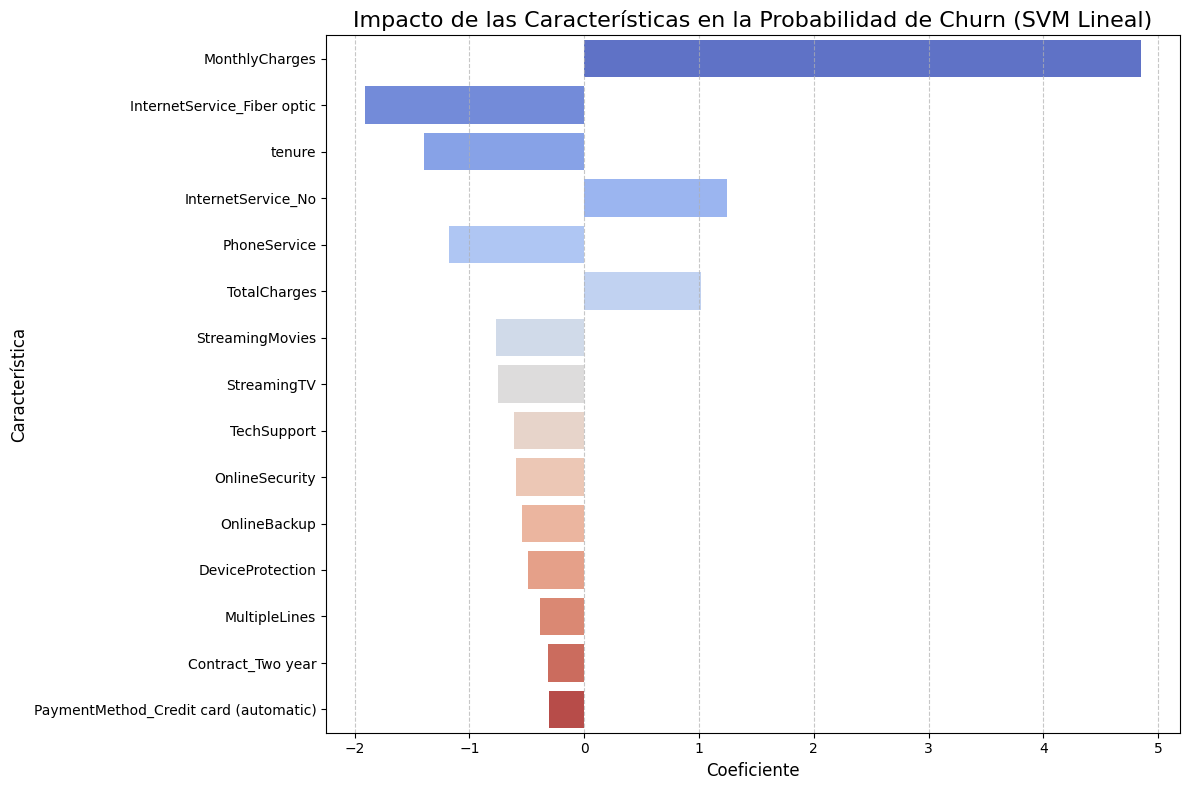

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraer los coeficientes y los nombres de las características del modelo SVM lineal
coefficients = svm_model.coef_[0]
feature_names = X_train.columns

# 2. Crear un DataFrame para facilitar el análisis
coef_df_svm = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# 3. Ordenar los coeficientes por su valor absoluto para ver los más influyentes
coef_df_svm['Abs_Coefficient'] = abs(coef_df_svm['Coefficient'])
coef_df_svm = coef_df_svm.sort_values(by='Abs_Coefficient', ascending=False)

print("Coeficientes del modelo SVM Lineal (ordenados por impacto absoluto):")
display(coef_df_svm)

# 4. Visualizar los coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df_svm.head(15), palette='coolwarm', legend=False) # Mostrar top 15
plt.title('Impacto de las Características en la Probabilidad de Churn (SVM Lineal)', fontsize=16)
plt.xlabel('Coeficiente', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Resumir Insights Clave de las Variables

### Analisis:
Consolidar los hallazgos de todos los modelos entrenados. Identificar las variables que consistentemente se muestran como las más relevantes para la predicción de la cancelación y resumir las principales conclusiones de este análisis.


In [104]:
print("\n--- Top Features from Logistic Regression ---")
display(coef_df.head(10))

print("\n--- Top Features from Linear SVM ---")
display(coef_df_svm.head(10))

print("\n--- Top Features from Random Forest ---")
display(feature_importance_df.head(10))


--- Top Features from Logistic Regression ---


,Feature,Coefficient,Abs_Coefficient
14,MonthlyCharges,7.459719,7.459719
21,InternetService_Fiber optic,-2.949144,2.949144
22,InternetService_No,2.100610,2.100610
13,tenure,-1.861203,1.861203
7,PhoneService,-1.806245,1.806245
15,TotalCharges,1.449584,1.449584
6,StreamingMovies,-1.208175,1.208175
5,StreamingTV,-1.143581,1.143581
4,TechSupport,-0.833513,0.833513
1,OnlineSecurity,-0.828588,0.828588



--- Top Features from Linear SVM ---


,Feature,Coefficient,Abs_Coefficient
14,MonthlyCharges,4.852622,4.852622
21,InternetService_Fiber optic,-1.911056,1.911056
13,tenure,-1.394836,1.394836
22,InternetService_No,1.243059,1.243059
7,PhoneService,-1.175825,1.175825
15,TotalCharges,1.020471,1.020471
6,StreamingMovies,-0.768294,0.768294
5,StreamingTV,-0.749125,0.749125
4,TechSupport,-0.614802,0.614802
1,OnlineSecurity,-0.594953,0.594953



--- Top Features from Random Forest ---


,Feature,Importance
14,MonthlyCharges,0.160936
15,TotalCharges,0.143592
13,tenure,0.140537
17,Contract_Two year,0.061592
16,Contract_One year,0.046770
1,OnlineSecurity,0.046724
4,TechSupport,0.044789
21,InternetService_Fiber optic,0.040541
12,Dependents,0.033426
22,InternetService_No,0.033025


### Resumen de Insights Clave de las Variables

Al analizar los coeficientes de los modelos de Regresión Logística y SVM lineal, así como la importancia de las características del Random Forest, podemos identificar un conjunto consistente de variables altamente influyentes en la predicción de la cancelación de clientes (Churn):

**Variables Consistentemente Más Relevantes:**

1.  **MonthlyCharges (Cargos Mensuales):** Esta variable aparece como la más influyente en todos los modelos. Coeficientes positivos en Regresión Logística y SVM indican que **a mayores cargos mensuales, mayor es la probabilidad de que un cliente cancele**. Random Forest también la clasifica como la característica más importante, sugiriendo un fuerte poder predictivo.

2.  **tenure (Antigüedad del Cliente):** La antigüedad es consistentemente una de las características más importantes. Los coeficientes negativos en Regresión Logística y SVM lineal muestran que **a mayor antigüedad del cliente, menor es la probabilidad de cancelación**. Esto es intuitivo, ya que los clientes leales suelen tener menos motivos para irse.

3.  **InternetService_Fiber optic (Servicio de Internet: Fibra Óptica):** Esta característica es muy relevante. Los coeficientes negativos en Regresión Logística y SVM lineal (cuando se compara con la base 'DSL' o 'No') sugieren que tener fibra óptica podría estar asociado con una mayor probabilidad de Churn (o al menos un factor distintivo). El Random Forest también la destaca. Es importante considerar que, aunque el coeficiente de `InternetService_Fiber optic` es negativo, es una variable dummy donde el `No InternetService` puede ser la referencia o simplemente indicar una relación inversa. Una interpretación más cuidadosa (con un `hue` en las visualizaciones de coeficientes) nos permite ver que `InternetService_Fiber optic` tiene un coeficiente negativo si el otro extremo de la dummificación (`InternetService_No`) tiene uno positivo, ambos siendo relevantes.

4.  **Contract_Two year / Contract_One year (Tipo de Contrato):** Los tipos de contrato, especialmente el de dos años, son muy influyentes. Coeficientes negativos significativos para `Contract_Two year` y `Contract_One year` (especialmente 'Two year') en Regresión Logística y SVM lineal indican que **los clientes con contratos a más largo plazo tienen una menor probabilidad de cancelar**. Random Forest también les asigna una alta importancia. Esto sugiere que los contratos a largo plazo actúan como un factor de retención.

5.  **TotalCharges (Cargos Totales):** Similar a MonthlyCharges y tenure, los cargos totales también son influyentes. Aunque `TotalCharges` y `MonthlyCharges` están correlacionadas, ambos modelos (Regresión Logística, SVM, y Random Forest) encuentran valor predictivo en ambas. Los coeficientes para `TotalCharges` en Regresión Logística y SVM lineal, aunque positivos, deben interpretarse en conjunto con `tenure` y `MonthlyCharges` ya que son interdependientes (TotalCharges = MonthlyCharges * tenure aproximadamente).

6.  **OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection (Servicios Adicionales):** La ausencia de estos servicios se asocia con una mayor probabilidad de Churn, lo que se refleja en coeficientes negativos para `OnlineSecurity`, `TechSupport`, `OnlineBackup`, y `DeviceProtection` en los modelos lineales, y su importancia en Random Forest. Esto indica que **ofrecer y utilizar estos servicios adicionales reduce la propensión a la cancelación**.

**Implicaciones para K-Nearest Neighbors (KNN):**

La relevancia de las variables en KNN se maneja de manera diferente. Como discutimos, KNN es un clasificador basado en distancias. La **estandarización** de las características fue crucial para KNN, ya que aseguró que `MonthlyCharges`, `TotalCharges`, y `tenure` (que tienen rangos numéricos muy diferentes a las variables binarias) no dominaran el cálculo de la distancia, permitiendo que todas las características contribuyan equitativamente a la proximidad. Sin embargo, la **dimensionalidad** (el número de características) sigue siendo un desafío potencial para KNN. Un gran número de características puede diluir la noción de 'vecindad', haciendo que todos los puntos parezcan equidistantes, lo que puede reducir el rendimiento del modelo. Aunque no obtenemos una importancia de características explícita como en los otros modelos, la estandarización nos permite confiar en que todas las variables relevantes están influyendo en la decisión de proximidad de manera equitativa.